<a href="https://colab.research.google.com/github/DussaRakesh/Detecting-Fraudulent-Job-Postings-Using-Traditional-NLP-and-Machine-Learning-Dissertation/blob/main/Fraud_Job_Postings_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
# Importing required libraries
import numpy as np
import pandas as pd

# Text + regex
import re
import string

# Visuals
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [41]:
!pip -q install datasets
from datasets import load_dataset

In [42]:
#Loading Dataset

train_url = "https://huggingface.co/datasets/difraud/difraud/resolve/main/job_scams/train.jsonl"
val_url   = "https://huggingface.co/datasets/difraud/difraud/resolve/main/job_scams/validation.jsonl"
test_url  = "https://huggingface.co/datasets/difraud/difraud/resolve/main/job_scams/test.jsonl"

ds = load_dataset(
    "json",
    data_files={
        "train": train_url,
        "validation": val_url,
        "test": test_url
    }
)

print(ds)
df_train = ds["train"].to_pandas()
df_val   = ds["validation"].to_pandas()
df_test  = ds["test"].to_pandas()

df_train.head()

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 11436
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1429
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1430
    })
})


,text,label
0,The Role: To lead and develop our cutting edge...,0
1,We are looking for a creative and proficient i...,0
2,Qubit: Cutting Edge Big Data Engineering Qubit...,0
3,(We have more than 1500+ Job openings in our w...,0
4,Gata Labs is a Toronto based Platform­as­a­ser...,0


In [43]:
#Checking Data shape
print("Train shape:", df_train.shape)
print("Val shape:", df_val.shape)
print("Test shape:", df_test.shape)

print("\nColumns:", df_train.columns.tolist())
print("\nLabel values:", df_train["label"].unique())

df_train.head()

Train shape: (11436, 2)
Val shape: (1429, 2)
Test shape: (1430, 2)

Columns: ['text', 'label']

Label values: [0 1]


,text,label
0,The Role: To lead and develop our cutting edge...,0
1,We are looking for a creative and proficient i...,0
2,Qubit: Cutting Edge Big Data Engineering Qubit...,0
3,(We have more than 1500+ Job openings in our w...,0
4,Gata Labs is a Toronto based Platform­as­a­ser...,0


label
0    10957
1      479
Name: count, dtype: int64


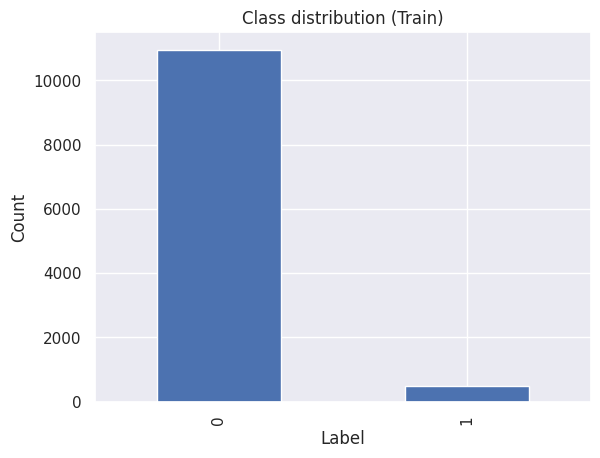


Class %:
label
0    95.81
1     4.19
Name: count, dtype: float64


In [44]:
# Distribution plot for classwise
label_counts = df_train["label"].value_counts().sort_index()
print(label_counts)

import matplotlib.pyplot as plt
plt.figure()
label_counts.plot(kind="bar")
plt.title("Class distribution (Train)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

# percentage
print("\nClass %:")
print((label_counts / len(df_train) * 100).round(2))

In [45]:
#Sample data with label=1(Fraud)
df_train[df_train["label"]==1]["text"].sample(3, random_state=42).to_list()

['Apply using below link We are currently seeking a dynamic individual with excellent communication skills looking for an exciting career opportunity. I.D. Images was founded in 1995, and is a leading manufacturer of converted label media for the Variable Information Printing (VIP) market. We specialize in providing label solutions for product and package identification across varied markets including Transport and Logistics, Retail, Food and Beverage, Office Products, Consumer Durables and Healthcare. I.D. Images offers a comprehensive product offering for VIP printing technologies including: Thermal Transfer, Ribbons, Direct Thermal, Ink Jet and Laser Cut Sheet media, on various paper and film or synthetic substrates. We offer a very comprehensive benefit package which includes: vacation, 401K, tuition reimbursement, health, vision and dental insurance. The salary for this position will be commensurate with individual experience. *All jobs will require passing of a background/drug ex

In [46]:
#Sample data with label=0(Non-Fraud)
df_train[df_train["label"]==0]["text"].sample(3, random_state=42).to_list()

["Our client offers the fitness experience of the 21st century. High intensity, bodyweight only workouts. Designed in a way that allows athletes to train together, compare themselves, and constantly improve their performance. Extremely efficient and motivating. Athletes receive their personalized, intelligent training instructions and connect themselves via our client's mobile and web apps. And this is just the beginning. Further development of the training system, a next level nutrition coach, social features, offline structures and a global expansion are just some of our client's topics in 2015. We are looking for a Head of Online Marketing You're experienced in leading Online Marketing teams and you'll bring the performance channels to the next level. You are in charge of managing and controlling the marketing campaigns across all online channels, including Facebook ads, SEM, SEO, CRM and affiliate marketing. Your Responsibilities Full responsibility for all online marketing channel

**Pre Processing**

In [47]:
import re

def clean_text(text):
    if not isinstance(text, str):
        text = str(text)

    # Removing  HTML
    text = re.sub(r"<[^>]+>", " ", text)

    # Replacing URLs, emails, phone numbers
    text = re.sub(r"(http|https)://\S+|www\.\S+", " URL ", text)
    text = re.sub(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", " EMAIL ", text)
    text = re.sub(r"\b(\+?\d[\d\-\s]{7,}\d)\b", " PHONE ", text)

    # Converting the text to Lowercase
    text = text.lower()

    # Removing extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Applying to all splits
df_train["clean_text"] = df_train["text"].apply(clean_text)
df_val["clean_text"]   = df_val["text"].apply(clean_text)
df_test["clean_text"]  = df_test["text"].apply(clean_text)

df_train[["text","clean_text"]].head(2)

,text,clean_text
0,The Role: To lead and develop our cutting edge...,the role: to lead and develop our cutting edge...
1,We are looking for a creative and proficient i...,we are looking for a creative and proficient i...


In [48]:
# Removing Duplicates
before = len(df_train)
df_train = df_train.drop_duplicates(subset=["clean_text"]).reset_index(drop=True)
after = len(df_train)
print("Duplicates removed:", before - after)

Duplicates removed: 6


In [49]:
# Text stats data
import matplotlib.pyplot as plt

df_train["word_count"] = df_train["clean_text"].str.split().apply(len)
df_train["char_len"] = df_train["clean_text"].str.len()

print(df_train[["word_count","char_len"]].describe())

         word_count      char_len
count  11430.000000  11430.000000
mean     187.111636   1245.888801
std      131.244844    883.402717
min        6.000000     44.000000
25%       99.000000    647.000000
50%      160.000000   1054.500000
75%      243.000000   1615.750000
max     2115.000000  14810.000000


In [50]:
# Removing outlier post with words less than 10
min_words = 10
before = len(df_train)
df_train = df_train[df_train["word_count"] >= min_words].reset_index(drop=True)
after = len(df_train)
print("Removed short posts:", before - after)
print("New train size:", df_train.shape)

Removed short posts: 12
New train size: (11418, 5)


In [51]:
# Applying to all splits
df_val["clean_text"] = df_val["text"].apply(clean_text)
df_test["clean_text"] = df_test["text"].apply(clean_text)

df_val["word_count"] = df_val["clean_text"].str.split().apply(len)
df_test["word_count"] = df_test["clean_text"].str.split().apply(len)

df_val = df_val[df_val["word_count"] >= min_words].reset_index(drop=True)
df_test = df_test[df_test["word_count"] >= min_words].reset_index(drop=True)

print("Val size:", df_val.shape)
print("Test size:", df_test.shape)

Val size: (1429, 4)
Test size: (1430, 4)


In [52]:
#Removing extremely long posts
wc_cap = df_train["word_count"].quantile(0.99)
before = len(df_train)
df_train = df_train[df_train["word_count"] <= wc_cap].reset_index(drop=True)
after = len(df_train)
print("Removed extreme long posts:", before - after)
print("99% word_count cap:", wc_cap)

Removed extreme long posts: 115
99% word_count cap: 641.6599999999999


In [53]:
# Checking duplicates in val set ad Test set
train_set = set(df_train["clean_text"])
val_overlap = sum(t in train_set for t in df_val["clean_text"])
test_overlap = sum(t in train_set for t in df_test["clean_text"])

print("Val overlap with train:", val_overlap)
print("Test overlap with train:", test_overlap)

Val overlap with train: 1
Test overlap with train: 1


**EDA**

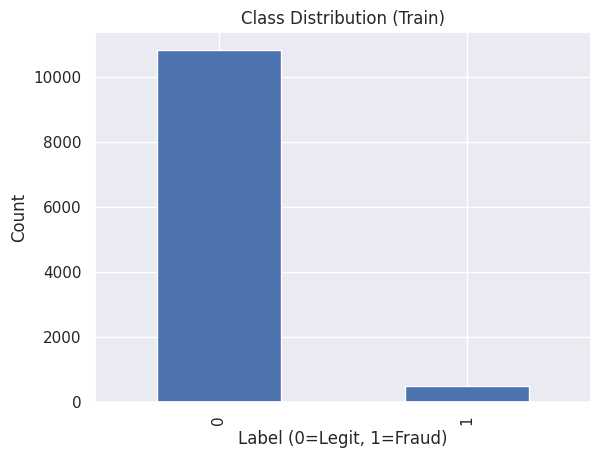

label
0    10834
1      469
Name: count, dtype: int64

Class %:
label
0    95.85
1     4.15
Name: count, dtype: float64


In [54]:
#Class Distribution Plot
import matplotlib.pyplot as plt

label_counts = df_train["label"].value_counts().sort_index()

plt.figure()
label_counts.plot(kind="bar")
plt.title("Class Distribution (Train)")
plt.xlabel("Label (0=Legit, 1=Fraud)")
plt.ylabel("Count")
plt.show()

print(label_counts)
print("\nClass %:")
print((label_counts / len(df_train) * 100).round(2))

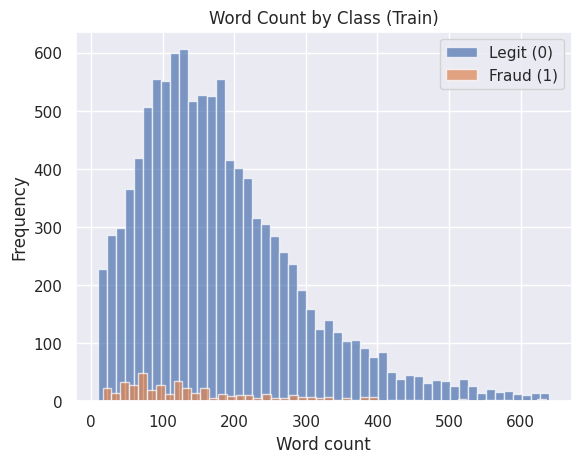

In [55]:
# Word count by class in train set
fraud_wc = df_train[df_train["label"]==1]["word_count"]
legit_wc = df_train[df_train["label"]==0]["word_count"]

plt.figure()
plt.hist(legit_wc, bins=50, alpha=0.7, label="Legit (0)")
plt.hist(fraud_wc, bins=50, alpha=0.7, label="Fraud (1)")
plt.title("Word Count by Class (Train)")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.legend()
plt.show()

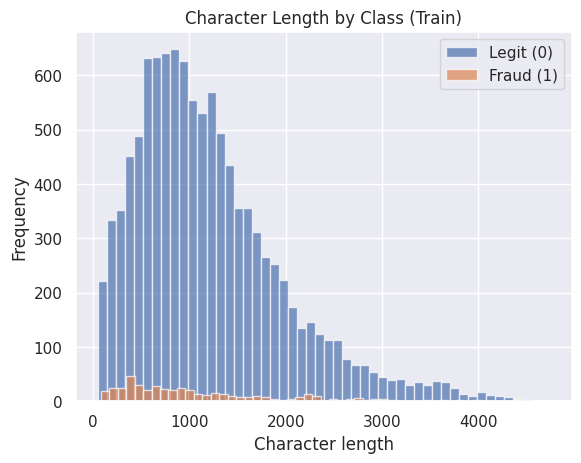

In [56]:
import matplotlib.pyplot as plt

df_train["char_len"] = df_train["clean_text"].str.len()

fraud_cl = df_train[df_train["label"]==1]["char_len"]
legit_cl = df_train[df_train["label"]==0]["char_len"]

plt.figure()
plt.hist(legit_cl, bins=50, alpha=0.7, label="Legit (0)")
plt.hist(fraud_cl, bins=50, alpha=0.7, label="Fraud (1)")
plt.title("Character Length by Class (Train)")
plt.xlabel("Character length")
plt.ylabel("Frequency")
plt.legend()
plt.show()

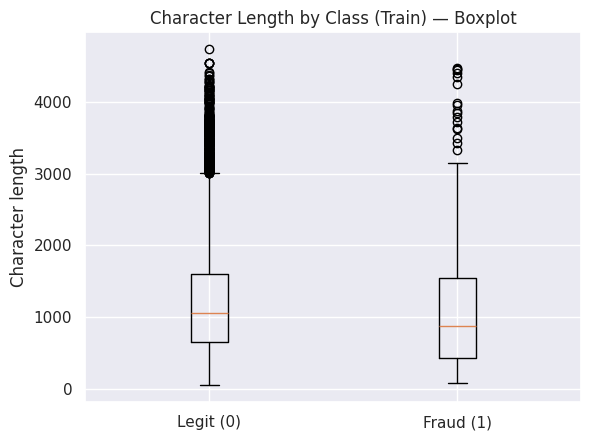

In [57]:
import matplotlib.pyplot as plt

fraud_cl = df_train[df_train["label"]==1]["char_len"]
legit_cl = df_train[df_train["label"]==0]["char_len"]

plt.figure()
plt.boxplot([legit_cl, fraud_cl], tick_labels=["Legit (0)", "Fraud (1)"])
plt.title("Character Length by Class (Train) — Boxplot")
plt.ylabel("Character length")
plt.show()

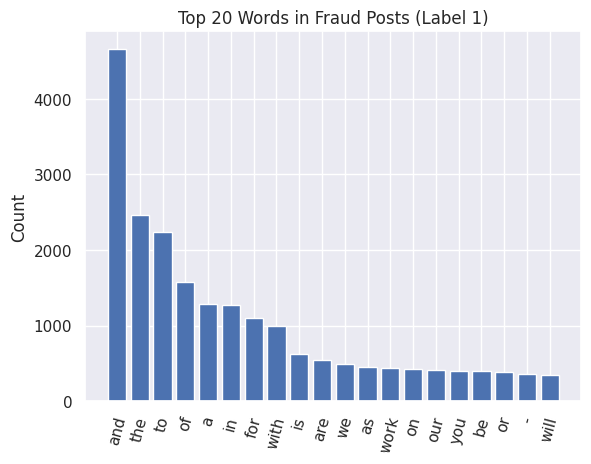

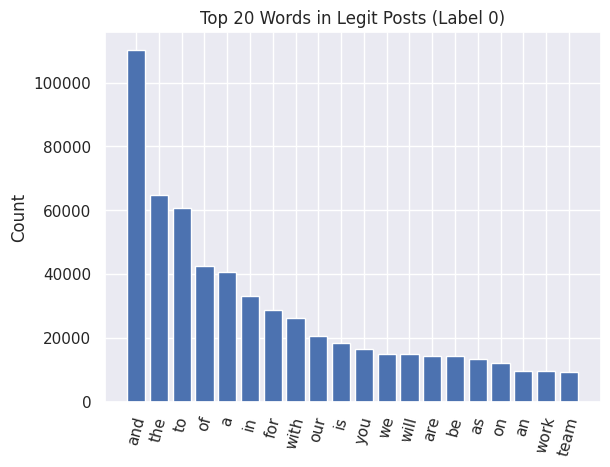

In [58]:
from collections import Counter
import matplotlib.pyplot as plt

def top_words(text_series, n=20):
    counter = Counter()
    for t in text_series:
        counter.update(t.split())
    return counter.most_common(n)

fraud_words = top_words(df_train[df_train["label"]==1]["clean_text"], 20)
legit_words = top_words(df_train[df_train["label"]==0]["clean_text"], 20)

def plot_top(items, title):
    words = [w for w,_ in items]
    counts = [c for _,c in items]
    plt.figure()
    plt.bar(words, counts)
    plt.title(title)
    plt.xticks(rotation=75)
    plt.ylabel("Count")
    plt.show()

plot_top(fraud_words, "Top 20 Words in Fraud Posts (Label 1)")
plot_top(legit_words, "Top 20 Words in Legit Posts (Label 0)")

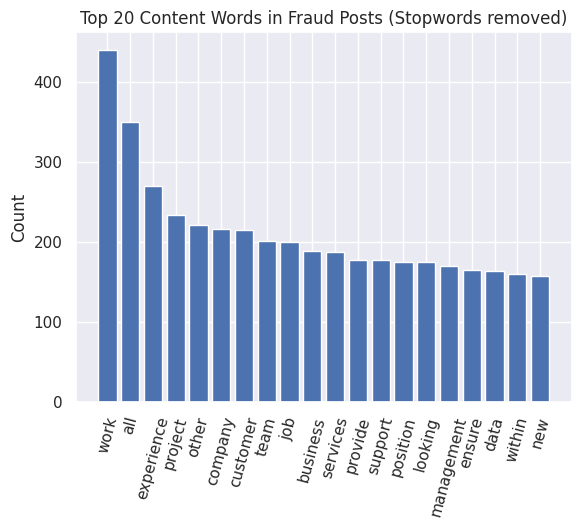

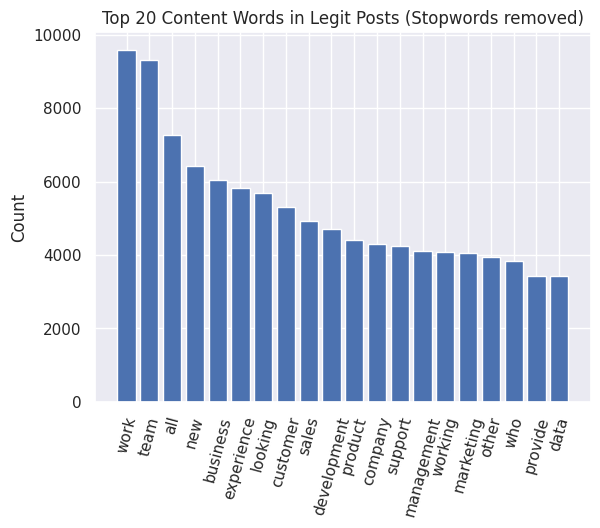

In [59]:
from collections import Counter
import matplotlib.pyplot as plt

# Simple stopword list (no extra installation)
stopwords = set([
    "a","an","the","and","or","to","of","in","on","for","with","is","are","was","were",
    "be","been","being","as","at","by","from","that","this","it","we","you","your","our",
    "they","them","their","he","she","his","her","i","me","my","but","not","will","would",
    "can","could","should","may","might","do","does","did","have","has","had"
])

def top_words_no_stop(text_series, n=20):
    counter = Counter()
    for t in text_series:
        tokens = [w for w in t.split() if w not in stopwords and len(w) > 2]
        counter.update(tokens)
    return counter.most_common(n)

fraud_words2 = top_words_no_stop(df_train[df_train["label"]==1]["clean_text"], 20)
legit_words2 = top_words_no_stop(df_train[df_train["label"]==0]["clean_text"], 20)

def plot_top(items, title):
    words = [w for w,_ in items]
    counts = [c for _,c in items]
    plt.figure()
    plt.bar(words, counts)
    plt.title(title)
    plt.xticks(rotation=75)
    plt.ylabel("Count")
    plt.show()

plot_top(fraud_words2, "Top 20 Content Words in Fraud Posts (Stopwords removed)")
plot_top(legit_words2, "Top 20 Content Words in Legit Posts (Stopwords removed)")

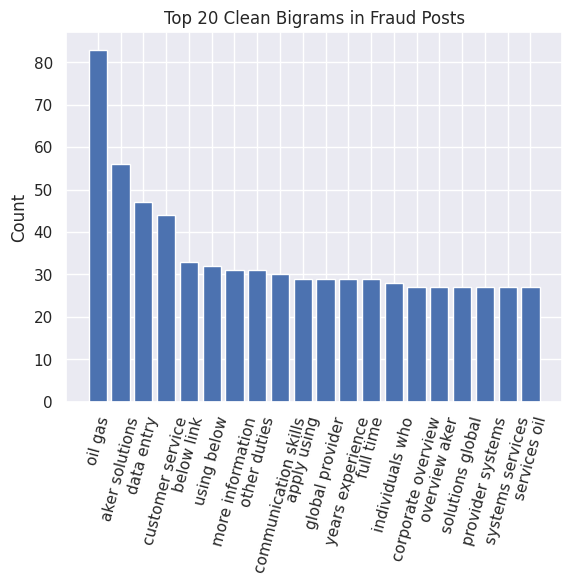

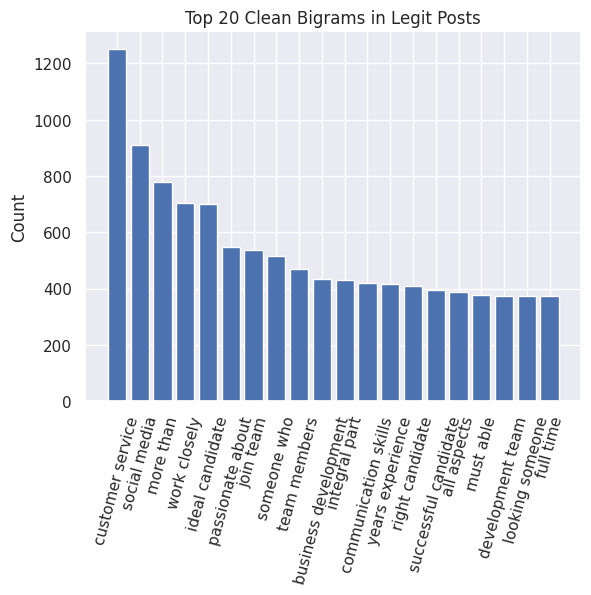

In [60]:
import re
from collections import Counter
import matplotlib.pyplot as plt

def clean_tokens_for_eda(text):
    tokens = text.split()
    # keeping only alphabetic tokens and length >= 3, remove stopwords
    tokens = [t for t in tokens if t.isalpha() and len(t) >= 3 and t not in stopwords]
    return tokens

def top_bigrams_clean(text_series, n=20):
    counter = Counter()
    for t in text_series:
        toks = clean_tokens_for_eda(t)
        bigrams = zip(toks, toks[1:])
        counter.update([" ".join(b) for b in bigrams])
    return counter.most_common(n)

fraud_bi2 = top_bigrams_clean(df_train[df_train["label"]==1]["clean_text"], 20)
legit_bi2 = top_bigrams_clean(df_train[df_train["label"]==0]["clean_text"], 20)

def plot_top(items, title):
    words = [w for w,_ in items]
    counts = [c for _,c in items]
    plt.figure()
    plt.bar(words, counts)
    plt.title(title)
    plt.xticks(rotation=75)
    plt.ylabel("Count")
    plt.show()

plot_top(fraud_bi2, "Top 20 Clean Bigrams in Fraud Posts")
plot_top(legit_bi2, "Top 20 Clean Bigrams in Legit Posts")

### Feature Extraction (TF-IDF)

In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF Vectorizer (unigrams + bigrams)
tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=3,          # ignoring very rare terms
    max_df=0.90,       # ignoring overly common terms
    max_features=50000 # limit vocabulary size
)

X_train = tfidf.fit_transform(df_train["clean_text"])
X_val   = tfidf.transform(df_val["clean_text"])
X_test  = tfidf.transform(df_test["clean_text"])

y_train = df_train["label"].values
y_val   = df_val["label"].values
y_test  = df_test["label"].values

print("TF-IDF train shape:", X_train.shape)
print("TF-IDF val shape:", X_val.shape)
print("TF-IDF test shape:", X_test.shape)

TF-IDF train shape: (11303, 50000)
TF-IDF val shape: (1429, 50000)
TF-IDF test shape: (1430, 50000)


Model 1: Logistic Regression

Confusion Matrix (Validation):
[[1326   43]
 [  12   48]]


<Figure size 640x480 with 0 Axes>

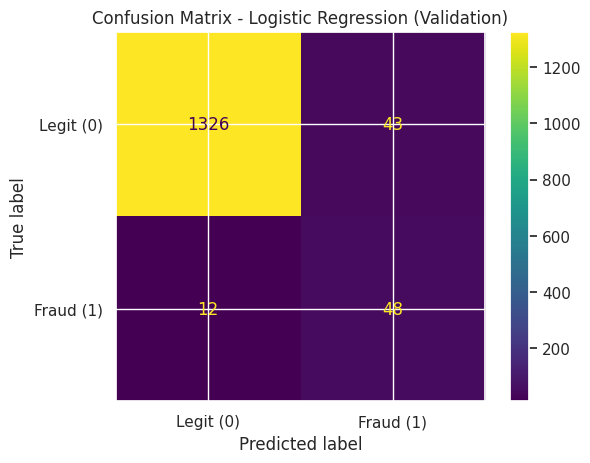


Classification Report (Validation):
              precision    recall  f1-score   support

           0     0.9910    0.9686    0.9797      1369
           1     0.5275    0.8000    0.6358        60

    accuracy                         0.9615      1429
   macro avg     0.7593    0.8843    0.8077      1429
weighted avg     0.9716    0.9615    0.9652      1429


ROC-AUC (Validation): 0.9466033601168736


In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train Logistic Regression (imbalance handling)
lr = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    n_jobs=-1
)

lr.fit(X_train, y_train)

# Predict on validation
val_pred = lr.predict(X_val)

# Confusion matrix (numbers + plot)
cm = confusion_matrix(y_val, val_pred)

print("Confusion Matrix (Validation):")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit (0)", "Fraud (1)"])
plt.figure()
disp.plot(values_format="d")
plt.title("Confusion Matrix - Logistic Regression (Validation)")
plt.show()

# Classification report
print("\nClassification Report (Validation):")
print(classification_report(y_val, val_pred, digits=4))

# ROC-AUC using probabilities
val_proba = lr.predict_proba(X_val)[:, 1]
print("\nROC-AUC (Validation):", roc_auc_score(y_val, val_proba))

Model 2: SVM

Confusion Matrix (Validation) - Linear SVM:
[[1357   12]
 [  18   42]]


<Figure size 640x480 with 0 Axes>

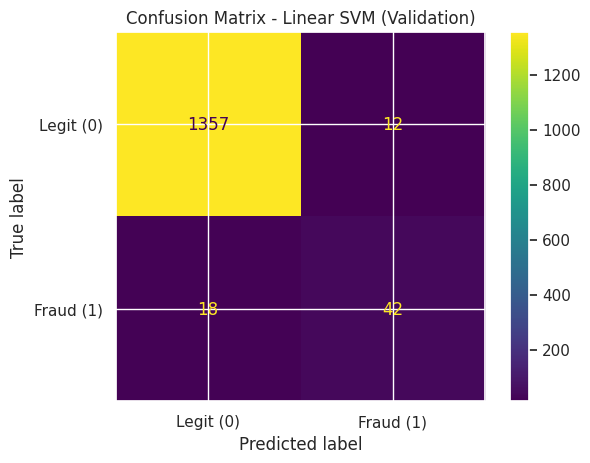


Classification Report (Validation) - Linear SVM:
              precision    recall  f1-score   support

           0     0.9869    0.9912    0.9891      1369
           1     0.7778    0.7000    0.7368        60

    accuracy                         0.9790      1429
   macro avg     0.8823    0.8456    0.8630      1429
weighted avg     0.9781    0.9790    0.9785      1429


ROC-AUC (Validation) - Linear SVM: 0.9329802775748721


In [63]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt

# Train Linear SVM (imbalance handling)
svm = LinearSVC(class_weight="balanced")
svm.fit(X_train, y_train)

# Predict on validation
svm_pred = svm.predict(X_val)

# Confusion matrix
cm_svm = confusion_matrix(y_val, svm_pred)
print("Confusion Matrix (Validation) - Linear SVM:")
print(cm_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=["Legit (0)", "Fraud (1)"])
plt.figure()
disp.plot(values_format="d")
plt.title("Confusion Matrix - Linear SVM (Validation)")
plt.show()

# Classification report
print("\nClassification Report (Validation) - Linear SVM:")
print(classification_report(y_val, svm_pred, digits=4))

# ROC-AUC using decision scores
svm_scores = svm.decision_function(X_val)
print("\nROC-AUC (Validation) - Linear SVM:", roc_auc_score(y_val, svm_scores))

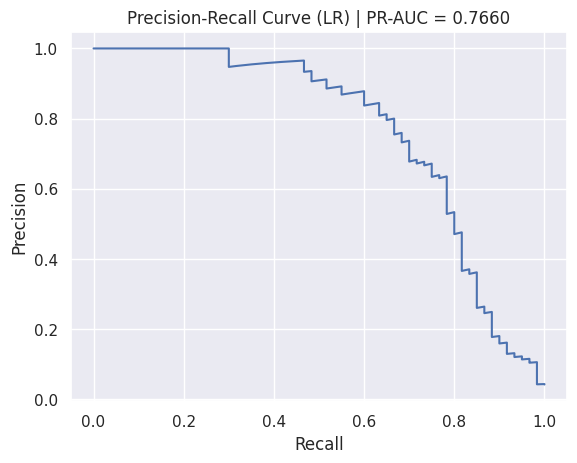

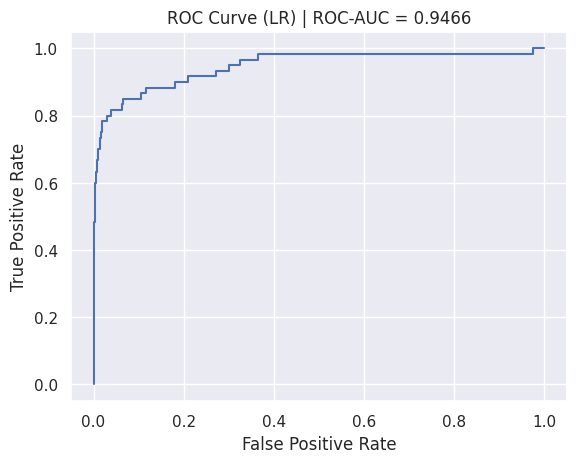

In [64]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, auc

lr_val_scores = lr.predict_proba(X_val)[:, 1]

# PR curve
prec, rec, _ = precision_recall_curve(y_val, lr_val_scores)
pr_auc = average_precision_score(y_val, lr_val_scores)
plt.figure()
plt.plot(rec, prec)
plt.title(f"Precision-Recall Curve (LR) | PR-AUC = {pr_auc:.4f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_val, lr_val_scores)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr)
plt.title(f"ROC Curve (LR) | ROC-AUC = {roc_auc:.4f}")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.show()

Model 3: MultinomialNB

Confusion Matrix (Val) - MultinomialNB:
 [[1369    0]
 [  51    9]]
              precision    recall  f1-score   support

           0     0.9641    1.0000    0.9817      1369
           1     1.0000    0.1500    0.2609        60

    accuracy                         0.9643      1429
   macro avg     0.9820    0.5750    0.6213      1429
weighted avg     0.9656    0.9643    0.9514      1429



<Figure size 640x480 with 0 Axes>

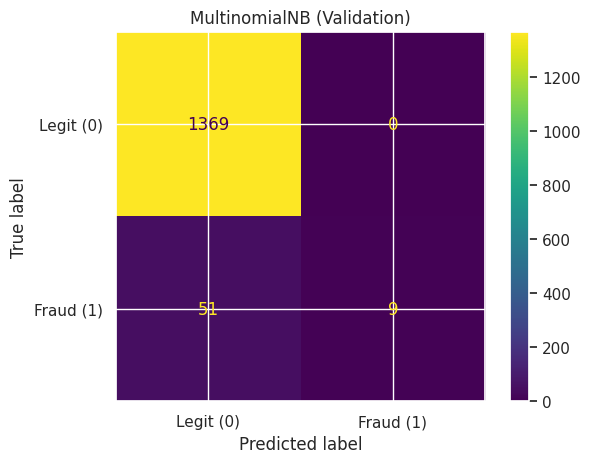

ROC-AUC: 0.8589481373265158
PR-AUC : 0.4194709071881989


In [65]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, average_precision_score
import matplotlib.pyplot as plt

mnb = MultinomialNB()
mnb.fit(X_train, y_train)

mnb_pred = mnb.predict(X_val)
cm = confusion_matrix(y_val, mnb_pred)
print("Confusion Matrix (Val) - MultinomialNB:\n", cm)
print(classification_report(y_val, mnb_pred, digits=4))

disp = ConfusionMatrixDisplay(cm, display_labels=["Legit (0)", "Fraud (1)"])
plt.figure(); disp.plot(values_format="d"); plt.title("MultinomialNB (Validation)"); plt.show()

mnb_scores = mnb.predict_proba(X_val)[:,1]
print("ROC-AUC:", roc_auc_score(y_val, mnb_scores))
print("PR-AUC :", average_precision_score(y_val, mnb_scores))

Model 4: ComplementNB

Confusion Matrix (Val) - ComplementNB:
 [[1368    1]
 [  46   14]]
              precision    recall  f1-score   support

           0     0.9675    0.9993    0.9831      1369
           1     0.9333    0.2333    0.3733        60

    accuracy                         0.9671      1429
   macro avg     0.9504    0.6163    0.6782      1429
weighted avg     0.9660    0.9671    0.9575      1429



<Figure size 640x480 with 0 Axes>

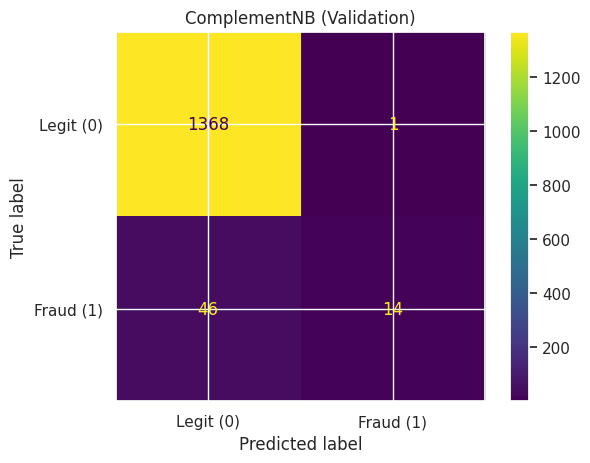

ROC-AUC: 0.8589481373265158
PR-AUC : 0.4194709071881989


In [66]:
from sklearn.naive_bayes import ComplementNB

cnb = ComplementNB()
cnb.fit(X_train, y_train)

cnb_pred = cnb.predict(X_val)
cm = confusion_matrix(y_val, cnb_pred)
print("Confusion Matrix (Val) - ComplementNB:\n", cm)
print(classification_report(y_val, cnb_pred, digits=4))

disp = ConfusionMatrixDisplay(cm, display_labels=["Legit (0)", "Fraud (1)"])
plt.figure(); disp.plot(values_format="d"); plt.title("ComplementNB (Validation)"); plt.show()

cnb_scores = cnb.predict_proba(X_val)[:,1]
print("ROC-AUC:", roc_auc_score(y_val, cnb_scores))
print("PR-AUC :", average_precision_score(y_val, cnb_scores))

Comaprision

In [67]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score


try:
    best_thr
except NameError:
    best_thr = 0.70

rows = []

def add_row(name, y_true, y_pred, scores):
    rows.append({
        "Model": name,
        "Fraud Precision": round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        "Fraud Recall": round(recall_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        "Fraud F1": round(f1_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        "ROC-AUC": round(roc_auc_score(y_true, scores), 4),
        "PR-AUC": round(average_precision_score(y_true, scores), 4),
    })

# Logistic Regression
lr_scores = lr.predict_proba(X_val)[:,1]
lr_pred = lr.predict(X_val)
add_row("Logistic Regression", y_val, lr_pred, lr_scores)

# Logistic Regression thresholded
lr_pred_thr = (lr_scores >= best_thr).astype(int)
add_row(f"LogReg thr={best_thr:.2f}", y_val, lr_pred_thr, lr_scores)

# Linear SVM
svm_scores = svm.decision_function(X_val)
svm_pred = svm.predict(X_val)
add_row("Linear SVM", y_val, svm_pred, svm_scores)

# Naive Bayes
mnb_scores = mnb.predict_proba(X_val)[:,1]
mnb_pred = mnb.predict(X_val)
add_row("MultinomialNB", y_val, mnb_pred, mnb_scores)

# ComplementNB
cnb_scores = cnb.predict_proba(X_val)[:,1]
cnb_pred = cnb.predict(X_val)
add_row("ComplementNB", y_val, cnb_pred, cnb_scores)

results_df = pd.DataFrame(rows).sort_values("Fraud F1", ascending=False).reset_index(drop=True)
results_df

,Model,Fraud Precision,Fraud Recall,Fraud F1,ROC-AUC,PR-AUC
0,Linear SVM,0.7778,0.7000,0.7368,0.9330,0.7936
1,LogReg thr=0.70,0.7593,0.6833,0.7193,0.9466,0.7660
2,Logistic Regression,0.5275,0.8000,0.6358,0.9466,0.7660
3,ComplementNB,0.9333,0.2333,0.3733,0.8589,0.4195
4,MultinomialNB,1.0000,0.1500,0.2609,0.8589,0.4195


Model Improvement

Confusion Matrix (TEST) - Linear SVM:
 [[1367    3]
 [  27   33]]

Classification Report (TEST) - Linear SVM:
               precision    recall  f1-score   support

           0     0.9806    0.9978    0.9891      1370
           1     0.9167    0.5500    0.6875        60

    accuracy                         0.9790      1430
   macro avg     0.9486    0.7739    0.8383      1430
weighted avg     0.9779    0.9790    0.9765      1430



<Figure size 640x480 with 0 Axes>

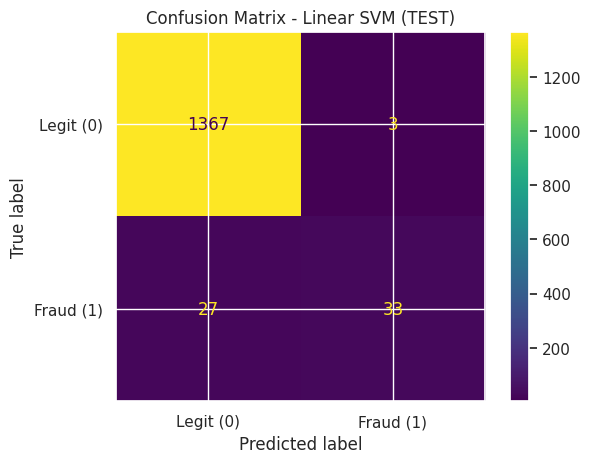

ROC-AUC (TEST) - Linear SVM: 0.9541484184914842
PR-AUC  (TEST) - Linear SVM: 0.7309300645323419


In [68]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, average_precision_score
import matplotlib.pyplot as plt

# Linear SVM
svm_test_pred = svm.predict(X_test)
cm = confusion_matrix(y_test, svm_test_pred)

print("Confusion Matrix (TEST) - Linear SVM:\n", cm)
print("\nClassification Report (TEST) - Linear SVM:\n", classification_report(y_test, svm_test_pred, digits=4))

disp = ConfusionMatrixDisplay(cm, display_labels=["Legit (0)", "Fraud (1)"])
plt.figure()
disp.plot(values_format="d")
plt.title("Confusion Matrix - Linear SVM (TEST)")
plt.show()

# ROC-AUC + PR-AUC using decision scores
svm_test_scores = svm.decision_function(X_test)
print("ROC-AUC (TEST) - Linear SVM:", roc_auc_score(y_test, svm_test_scores))
print("PR-AUC  (TEST) - Linear SVM:", average_precision_score(y_test, svm_test_scores))

In [69]:
# ERROR ANALYSIS on TEST set
test_df = df_test.copy()
test_df["pred"] = svm_test_pred  # from your test prediction cell

# False Positives: Legit (0) predicted Fraud (1)
fp = test_df[(test_df["label"]==0) & (test_df["pred"]==1)].head(5)

# False Negatives: Fraud (1) predicted Legit (0)
fn = test_df[(test_df["label"]==1) & (test_df["pred"]==0)].head(5)

print("FALSE POSITIVES (Legit predicted Fraud):")
for i, t in enumerate(fp["text"].tolist(), 1):
    print(f"\nFP {i}:\n{t[:700]}")

print("\nFALSE NEGATIVES (Fraud predicted Legit):")
for i, t in enumerate(fn["text"].tolist(), 1):
    print(f"\nFN {i}:\n{t[:700]}")

FALSE POSITIVES (Legit predicted Fraud):

FP 1:
Job Requirements: Minimum of 3 years of professional, full time accounting experience Minimum of 3 years of external or internal audit experience Experience working with clients from a variety of industries Experience with other accounting disciplines such tax preparation or bookkeeping

FP 2:
Initiate telephone calls to insurance companies requesting status of claims for the outstanding balances on patient accounts and taking appropriate action . Manage A/R accounts by ensuring accurate and timely follow-up. Resolve billing issues that have resulted in delay in payment. Establish and maintain excellent working relationship with internal and external clients. Adhering to SLA's as defined for the process.

FP 3:
Company: Dyson Corp. Pay: $18.50/hr Dyson Demonstrators work part-time as members of the Field Sales team to engage consumers in an energetic and confident manner and provide them with knowledgeable information about Dyson products

In [70]:
import numpy as np

feature_names = np.array(tfidf.get_feature_names_out())
coefs = lr.coef_[0]   # Logistic Regression coefficients

top_fraud = feature_names[np.argsort(coefs)[-20:]][::-1]
top_legit = feature_names[np.argsort(coefs)[:20]]

print("Top 20 terms pushing predictions towards FRAUD:")
print(top_fraud)

print("\nTop 20 terms pushing predictions towards LEGIT:")
print(top_legit)

Top 20 terms pushing predictions towards FRAUD:
['assistant' 'using below' 'below link' 'data entry' 'apply using'
 'engineering' 'link' 'administrative' 'entry' 'subsea' 'money'
 'administrative assistant' 'below' 'weather' 'earn' 'office' 'supplier'
 'perioperative' 'income' 'call']

Top 20 terms pushing predictions towards LEGIT:
['our' 'team' 're' 'user' 'in' 'we re' 'you ll' 'marketing' 'based' 'll'
 'web' 'digital' 'is' 'an' 'of' 'it' 'new' 'on' 'will' 'you will']


In [71]:
import numpy as np

feature_names = np.array(tfidf.get_feature_names_out())
coefs = lr.coef_[0]

# filter out very short tokens
def is_good_term(t):
    return (len(t) >= 4) and (" " in t or t.isalpha()) and (t not in ["will","your","with","this","that"])

sorted_idx = np.argsort(coefs)

top_legit = [feature_names[i] for i in sorted_idx if is_good_term(feature_names[i])][:20]
top_fraud = [feature_names[i] for i in sorted_idx[::-1] if is_good_term(feature_names[i])][:20]

print("Cleaner Top 20 Fraud terms:")
print(top_fraud)

print("\nCleaner Top 20 Legit terms:")
print(top_legit)

Cleaner Top 20 Fraud terms:
['assistant', 'using below', 'below link', 'data entry', 'apply using', 'engineering', 'link', 'administrative', 'entry', 'subsea', 'money', 'administrative assistant', 'below', 'weather', 'earn', 'office', 'supplier', 'perioperative', 'income', 'call']

Cleaner Top 20 Legit terms:
['team', 'user', 'we re', 'you ll', 'marketing', 'based', 'digital', 'you will', 'developer', 'media', 'content', 'website', 'growing', 'of our', 'candidate', 'right', 'is looking', 'creative', 'about', 'client']


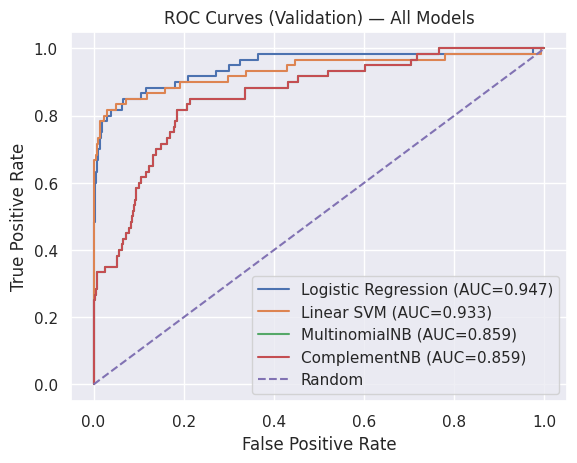

In [72]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Scores for each model
scores_dict = {
    "Logistic Regression": lr.predict_proba(X_val)[:, 1],
    "Linear SVM": svm.decision_function(X_val),
    "MultinomialNB": mnb.predict_proba(X_val)[:, 1],
    "ComplementNB": cnb.predict_proba(X_val)[:, 1]
}

plt.figure()
for name, scores in scores_dict.items():
    fpr, tpr, _ = roc_curve(y_val, scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.title("ROC Curves (Validation) — All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

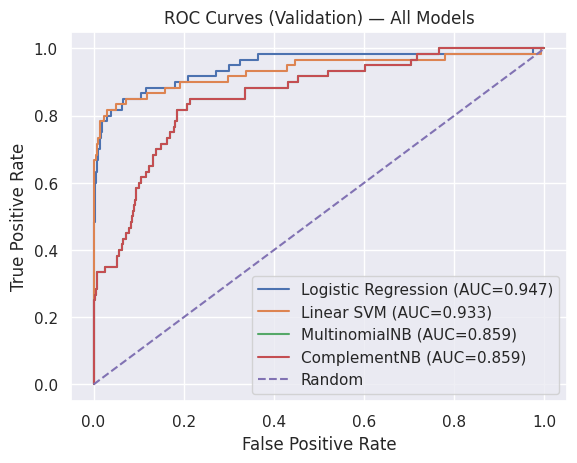

In [73]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Scores for each model
scores_dict = {
    "Logistic Regression": lr.predict_proba(X_val)[:, 1],
    "Linear SVM": svm.decision_function(X_val),
    "MultinomialNB": mnb.predict_proba(X_val)[:, 1],
    "ComplementNB": cnb.predict_proba(X_val)[:, 1]
}

plt.figure()
for name, scores in scores_dict.items():
    fpr, tpr, _ = roc_curve(y_val, scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.title("ROC Curves (Validation) — All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

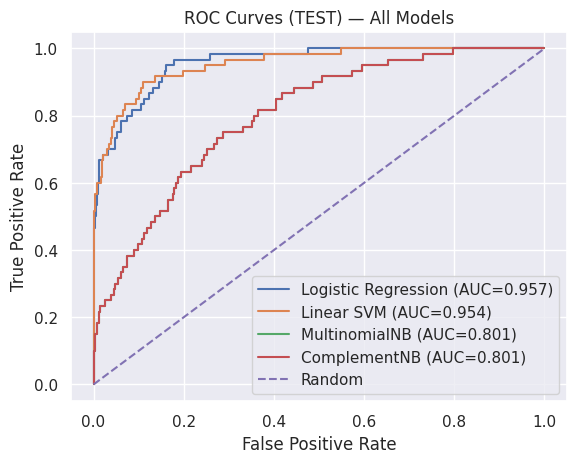

In [74]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

test_scores_dict = {
    "Logistic Regression": lr.predict_proba(X_test)[:, 1],
    "Linear SVM": svm.decision_function(X_test),
    "MultinomialNB": mnb.predict_proba(X_test)[:, 1],
    "ComplementNB": cnb.predict_proba(X_test)[:, 1]
}

plt.figure()
for name, scores in test_scores_dict.items():
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.title("ROC Curves (TEST) — All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

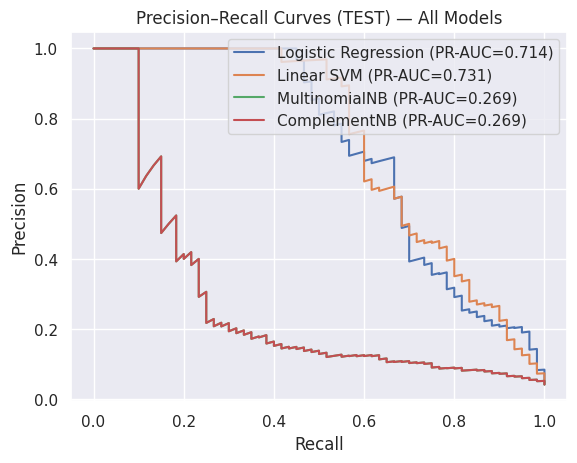

In [75]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

plt.figure()
for name, scores in test_scores_dict.items():
    prec, rec, _ = precision_recall_curve(y_test, scores)
    pr_auc = average_precision_score(y_test, scores)
    plt.plot(rec, prec, label=f"{name} (PR-AUC={pr_auc:.3f})")

plt.title("Precision–Recall Curves (TEST) — All Models")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

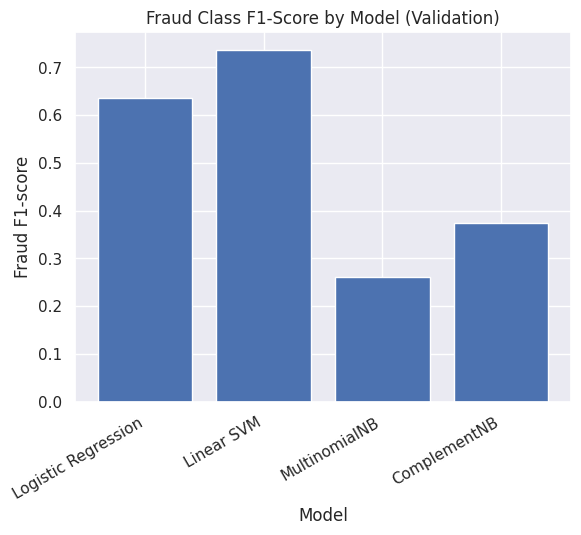

In [76]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, average_precision_score

# Validation scores
scores_dict = {
    "Logistic Regression": lr.predict_proba(X_val)[:, 1],
    "Linear SVM": svm.decision_function(X_val),
    "MultinomialNB": mnb.predict_proba(X_val)[:, 1],
    "ComplementNB": cnb.predict_proba(X_val)[:, 1]
}

# Predictions
preds_dict = {
    "Logistic Regression": lr.predict(X_val),
    "Linear SVM": svm.predict(X_val),
    "MultinomialNB": mnb.predict(X_val),
    "ComplementNB": cnb.predict(X_val)
}

models = list(preds_dict.keys())
fraud_f1 = [f1_score(y_val, preds_dict[m], pos_label=1, zero_division=0) for m in models]

plt.figure()
plt.bar(models, fraud_f1)
plt.title("Fraud Class F1-Score by Model (Validation)")
plt.xlabel("Model")
plt.ylabel("Fraud F1-score")
plt.xticks(rotation=30, ha="right")
plt.show()

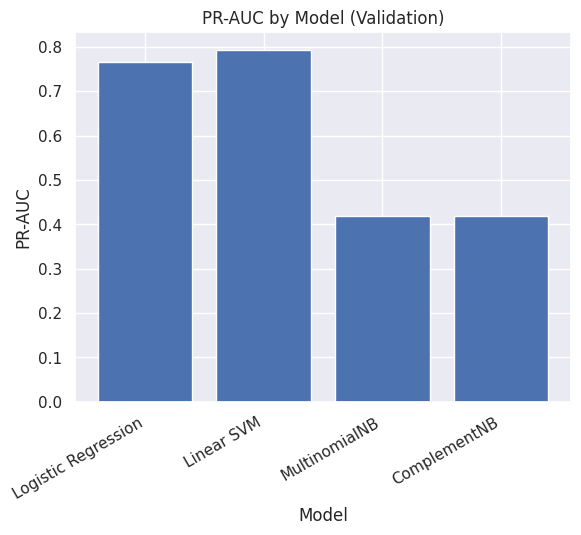

In [77]:
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score

models = list(scores_dict.keys())
pr_auc_vals = [average_precision_score(y_val, scores_dict[m]) for m in models]

plt.figure()
plt.bar(models, pr_auc_vals)
plt.title("PR-AUC by Model (Validation)")
plt.xlabel("Model")
plt.ylabel("PR-AUC")
plt.xticks(rotation=30, ha="right")
plt.show()

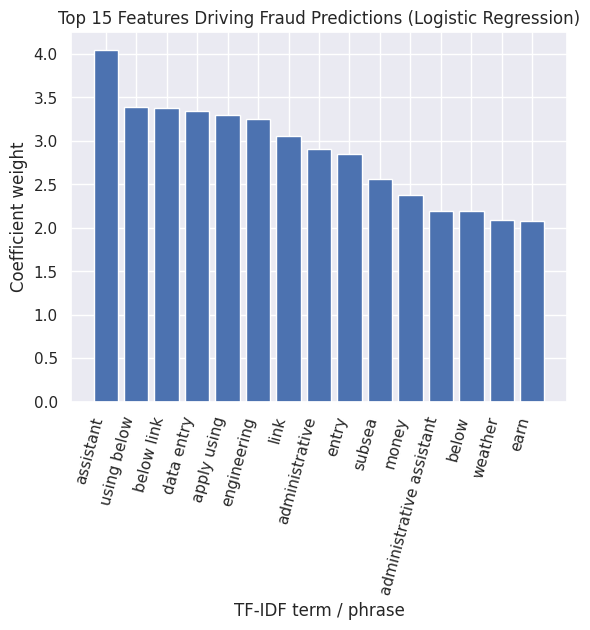

In [78]:
import numpy as np
import matplotlib.pyplot as plt

feature_names = np.array(tfidf.get_feature_names_out())
coefs = lr.coef_[0]

# top 15 fraud terms
top_idx = np.argsort(coefs)[-15:][::-1]
top_terms = feature_names[top_idx]
top_weights = coefs[top_idx]

plt.figure()
plt.bar(top_terms, top_weights)
plt.title("Top 15 Features Driving Fraud Predictions (Logistic Regression)")
plt.xlabel("TF-IDF term / phrase")
plt.ylabel("Coefficient weight")
plt.xticks(rotation=75, ha="right")
plt.show()